# Plant Disease Detection using CNN
Multi-class classification of plant leaf diseases from Kaggle dataset. Model is saved for deployment.

In [ ]:
!pip install tensorflow matplotlib scikit-learn seaborn

## Dataset Setup
**Download from Kaggle:** [PlantVillage Dataset](https://www.kaggle.com/datasets/emmarex/plantdisease)

```bash
# Uncomment to use Kaggle API:
# from google.colab import files; files.upload()  # upload kaggle.json
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d emmarex/plantdisease
# !unzip plantdisease.zip -d plant_disease
```

Expected folder structure:
```
plant_disease/PlantVillage/
    Apple___Apple_scab/
    Apple___Black_rot/
    Tomato___Late_blight/
    ...
```

### Download Dataset from Kaggle

First, upload your `kaggle.json` file. You can generate this from your Kaggle account settings (`Account` -> `API` -> `Create New API Token`).

In [ ]:
from google.colab import files

files.upload() # Upload kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"chhavia021","key":"42f1d4de1edbf870a56386b59d6ea3ee"}'}

In [ ]:
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:03<00:00, 187MB/s]



In [ ]:
!unzip plantdisease.zip -d plant_disease

Streaming output truncated to the last 5000 lines.
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08c033bd-fbc3-445a-88d1-1863070e52ce___YLCV_GCREC 2872.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG  
  inflating: plant_disease/plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG  
  inflating: plant_

Now that the dataset is downloaded and extracted, you can re-run the `Dataset Setup` cell above (cell `TA0GDhhe7KxU`) to load the data.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report

DATA_DIR = 'plant_disease/PlantVillage'  # Update path if needed
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_data = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training'
)
val_data = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation'
)

NUM_CLASSES = len(train_data.class_indices)
CLASS_NAMES = list(train_data.class_indices.keys())
print(f'Number of disease classes: {NUM_CLASSES}')
print('Sample classes:', CLASS_NAMES[:5])

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Number of disease classes: 15
Sample classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


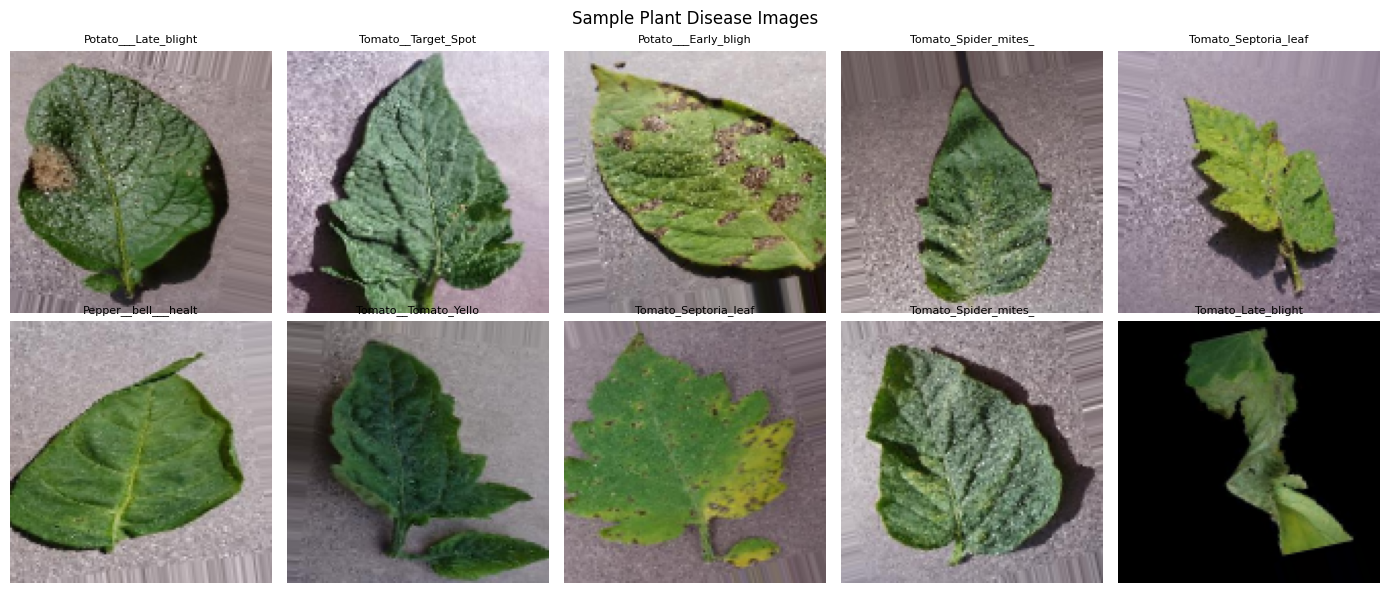

In [ ]:
# Visualize sample images
images, labels = next(train_data)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    class_idx = np.argmax(labels[i])
    ax.set_title(CLASS_NAMES[class_idx][:20], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample Plant Disease Images')
plt.tight_layout()
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='PlantDisease_CNN')

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "PlantDisease_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,615 (2.02 MB)

 Trainable params: 528,655 (2.02 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3),
    keras.callbacks.ModelCheckpoint('best_plant_model.h5', save_best_only=True)
]

history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,
    callbacks=callbacks
)

Epoch 1/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6911 - loss: 0.9377

517/517 ━━━━━━━━━━━━━━━━━━━━ 1084s 2s/step - accuracy: 0.7347 - loss: 0.7954 - val_accuracy: 0.5245 - val_loss: 2.1832 - learning_rate: 0.0010
Epoch 2/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8275 - loss: 0.5167

517/517 ━━━━━━━━━━━━━━━━━━━━ 1071s 2s/step - accuracy: 0.8414 - loss: 0.4757 - val_accuracy: 0.6858 - val_loss: 1.1433 - learning_rate: 0.0010
Epoch 3/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8792 - loss: 0.3617

517/517 ━━━━━━━━━━━━━━━━━━━━ 1080s 2s/step - accuracy: 0.8844 - loss: 0.3466 - val_accuracy: 0.7831 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 4/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9047 - loss: 0.2850

517/517 ━━━━━━━━━━━━━━━━━━━━ 1066s 2s/step - accuracy: 0.9065 - loss: 0.2770 - val_accuracy: 0.8806 - val_loss: 0.3473 - learning_rate: 0.0010
Epoch 5/5
517/517 ━━━━━━━━━━━━━━━━━━━━ 1081s 2s/step - accuracy: 0.9198 - loss: 0.2374 - val_accuracy: 0.7213 - val_loss: 0.9546 - learning_rate: 0.0010


In [ ]:
# Evaluation
val_loss, val_acc = model.evaluate(val_data)
print(f'Validation Accuracy: {val_acc:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 570ms/step - accuracy: 0.8743 - loss: 0.3496
Validation Accuracy: 0.8743


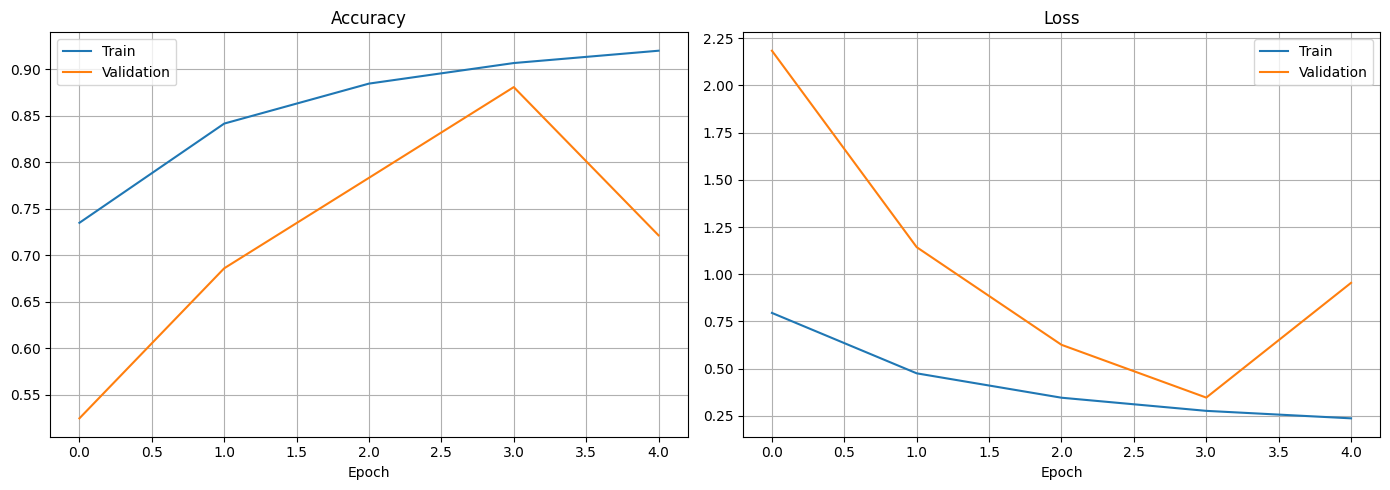

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Save model for deployment
model.save('plant_disease_model.h5')
print('Model saved as plant_disease_model.h5')

# Save class names
import json
with open('class_names.json', 'w') as f:
    json.dump(CLASS_NAMES, f)
print(f'Saved {NUM_CLASSES} class names to class_names.json')

In [ ]:
# Quick prediction function
from tensorflow.keras.preprocessing import image as keras_image

def predict_disease(img_path, model, class_names):
    img = keras_image.load_img(img_path, target_size=(128, 128))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, 0)
    preds = model.predict(img_array)[0]
    top3 = np.argsort(preds)[::-1][:3]
    print('Top-3 Predictions:')
    for idx in top3:
        print(f'  {class_names[idx]}: {preds[idx]*100:.2f}%')

# Usage: predict_disease('path/to/leaf.jpg', model, CLASS_NAMES)
print('Prediction function ready. Call: predict_disease(img_path, model, CLASS_NAMES)')